In [56]:
import os
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

In [73]:
#read human data
human_file_name = "example_data_2afc"
human_data = pd.read_csv(f"psychophysics/data/{human_file_name}.csv")

#read model data
model_file_name = "example_model_obj_2afc"
model_data = pd.read_csv(f"anns/results/{model_file_name}.csv")

if "n_back" in human_file_name:
    human_column = "correct_at_second_occurrence"
elif "ratings" in human_file_name:
    human_column = "rating"
else:
    human_column = "correct"

if "n_back"  in model_file_name or "ratings" in model_file_name:
    model_column = "score"
else:
    model_column = "accuracy"

#Change these file names to test on another task

In [64]:
human_data

# Each image is shown multiple times to different subjects and with different target/distractory pairings

,subject_id,reactionTime,choices_1,choices_2,correct,image_idx
0,357030,653.5,8,9,1.0,199
1,357030,640.2,4,3,1.0,87
2,357030,512.5,7,9,1.0,180
3,357030,744.2,2,8,1.0,44
4,357030,582.6,7,5,1.0,144
...,...,...,...,...,...,...
4315,615454,872.7,9,0,1.0,180
4316,615454,821.2,7,0,1.0,0
4317,615454,860.4,4,9,1.0,85
4318,615454,754.4,4,5,1.0,87


In [65]:
model_data

#Models output an accuracy value per image

,image_name,image_index,accuracy
0,im0.png,0,0.999848
1,im1.png,1,0.999904
2,im2.png,2,0.998945
3,im3.png,3,0.584459
4,im4.png,4,0.999957
...,...,...,...
195,im195.png,195,0.999702
196,im196.png,196,0.999892
197,im197.png,197,0.999767
198,im198.png,198,0.999836


In [66]:
#Get list of indices and sort it
indices = list(sorted(human_data["image_idx"].unique()))

In [74]:
#now store the image-level scores in two separate arrays

human_scores = []
model_scores = []
for im in indices:
    #Select the rows containing scores for image im
    temp_humans = human_data[human_data["image_idx"] == im]
    #compute the mean score for this image
    human_score = temp_humans[human_column].mean()
    human_scores.append(human_score)

    #now we do the same for the model
    temp_model = model_data[model_data["image_index"] == im]
    model_score = temp_model[model_column].mean()
    model_scores.append(model_score)

human_scores = np.array(human_scores)
model_scores = np.array(model_scores)

In [75]:
#compare the mean accuracy
print("Mean human accuracy:", np.mean(human_scores))
print("Mean model accuracy:", np.mean(model_scores))

Mean human accuracy: 0.9650021495685145
Mean model accuracy: 0.9851802446775967


Text(0, 0.5, 'Model scores')

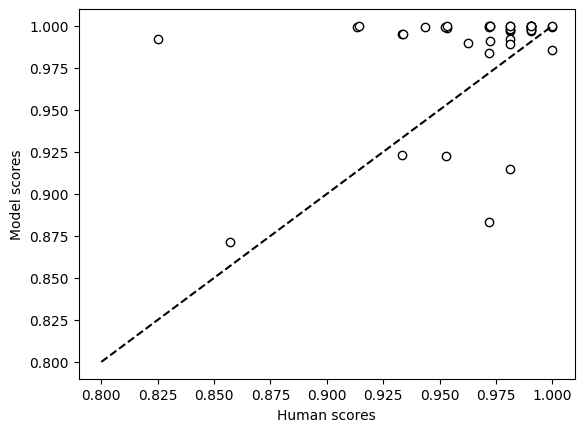

In [77]:
#Compare the image level scores

plt.scatter(human_scores, model_scores, color="white", edgecolor="black")
plt.plot([0.8, 1.0], [0.8, 1.0], color="black", linestyle="--")
plt.xlabel("Human scores")
plt.ylabel("Model scores")

In [82]:
# If humans and models perform similarly on the task, their scores will be correlated:

spearmanr(human_scores, model_scores)

SignificanceResult(statistic=np.float64(0.3099793685819656), pvalue=np.float64(0.051587337997766644))

In [78]:
# A note about noise ceiling: human scores represent an average across repetitions (of trials and subjects).
# Human subjects are not deterministic: given the same image, they can make different choices at different points in time.
# This variability is called noise. 
# We want to estimate how much noise there is in the data and ensure that our inference do not depend on this noise.
# To estimate it, we split the human data into two halves, and look at the correlation per image. And we repeat this many times.
# If it is high, there is not much noise. If it is low, we need to collect more data...

from scipy.stats import pearsonr 

def spearmanbrown_correction(var):  # Spearman Brown Correct the correlation value
    spc_var = (2 * var) / (1 + var)
    return spc_var

def compute_reliability(data, axis=1, reps=50):
    rng = np.random.default_rng()
    reliability = []
    for r in range(reps):
        perm = rng.permutation(data.shape[axis])
        indexer = [slice(None)] * data.ndim
        indexer[axis] = perm
        data_shuffled = data[tuple(indexer)]
        split1, split2 = np.array_split(data_shuffled, 2, axis=axis)
        split_mean1 = np.nanmean(split1, axis=axis)
        split_mean2 = np.nanmean(split2, axis=axis)

        corr = pearsonr(split_mean1, split_mean2)[0]
        reliability.append(spearmanbrown_correction(corr))
    return np.array(reliability)

In [79]:
# Store all the scores (without averaging the responses)

#First we want to know what is the max number of trials per image
n_max = 0
for im in indices:
    #Select the rows containing scores for image im
    temp_humans = human_data[human_data["image_idx"] == im]
    n = len(temp_humans)
    if n > n_max:
        n_max = n

all_human_scores = np.zeros((len(indices), n_max))+np.nan
for i, im in enumerate(indices):
    #Select the rows containing scores for image im
    temp_humans = human_data[human_data["image_idx"] == im]
    #compute the mean score for this image
    all_human_scores[i, :len(temp_humans)] = np.array(temp_humans["correct"], dtype=int)

/Users/sabine/Library/Python/3.9/lib/python/site-packages/pandas/core/series.py:1036: RuntimeWarning: invalid value encountered in cast
  arr = np.asarray(values, dtype=dtype)


In [80]:
reliability = compute_reliability(all_human_scores, axis=1, reps=5)

In [85]:
spearmanr(human_scores, model_scores)[0]/np.sqrt(reliability.mean())

np.float64(0.33208546077545)